# Import libraries :

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding :

In [5]:
customer = pd.read_csv("customer_info.csv")
churn = pd.read_csv("churn_labels.csv")
usage = pd.read_csv("usage_data.csv")

### Customer info : 

#### First 10 lines : 

In [47]:
customer.head(10)

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
0,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20
1,CUST_1,NaN,Female,Suburban,Prepaid,38.94,2020-01-25
2,CUST_2,46.0,Female,Rural,Monthly,48.56,2022-08-31
3,CUST_3,NaN,Female,Urban,Prepaid,24.22,2018-12-09
4,CUST_4,60.0,Male,Rural,Monthly,67.86,2022-12-28
5,CUST_5,25.0,Female,Urban,Prepaid,44.77,2022-08-02
6,CUST_6,38.0,Female,Suburban,Yearly,38.67,2022-11-05
7,CUST_7,NaN,Female,Rural,Monthly,40.41,2018-12-25
8,CUST_8,36.0,Male,Suburban,Yearly,50.25,2022-12-20
9,CUST_9,NaN,Male,Urban,Yearly,51.79,2022-10-16


#### the shape of the dataset : 

In [10]:
customer.shape

(10200, 7)

#### Name of the columns :

In [12]:
customer.columns

Index(['CustomerID', 'Age', 'Gender', 'Region', 'ContractType',
       'MonthlyCharges', 'SignupDate'],
      dtype='object')

#### Data info : 

In [13]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      10200 non-null  object 
 1   Age             6617 non-null   float64
 2   Gender          10200 non-null  object 
 3   Region          10200 non-null  object 
 4   ContractType    10200 non-null  object 
 5   MonthlyCharges  10200 non-null  float64
 6   SignupDate      10200 non-null  object 
dtypes: float64(2), object(5)
memory usage: 557.9+ KB


#### Type of variables : 

In [17]:
customer.dtypes

CustomerID         object
Age               float64
Gender             object
Region             object
ContractType       object
MonthlyCharges    float64
SignupDate         object
dtype: object

##### we have only 2 numerical variables, the others are textual

#### Genral statical info : 

In [16]:
customer.describe()

,Age,MonthlyCharges
count,6617.000000,10200.000000
mean,43.424664,50.961995
std,14.966108,21.423985
min,18.000000,-6.720000
25%,31.000000,39.767500
50%,43.000000,50.000000
75%,56.000000,60.460000
max,69.000000,390.300000


#### Missing values :

In [18]:
print("missing value : " , customer.isnull().sum())

missing value :  CustomerID           0
Age               3583
Gender               0
Region               0
ContractType         0
MonthlyCharges       0
SignupDate           0
dtype: int64


##### we have 3583 missing values in the column age. The others have not any missing values

#### duplicated values : 

In [20]:
print(" total dublicate :" , customer.duplicated().sum())

 total dublicate : 195


#### inconsistencies :

In [8]:
for i in [ "Gender" , "Region" , "ContractType" ] : 
    print(i)
    print(customer[i].unique())

Gender
['Male' 'Female']
Region
['Urban' 'Suburban' 'Rural']
ContractType
['Yearly' 'Prepaid' 'Monthly']


In [26]:
customer.select_dtypes(include='number').min()

Age               18.00
MonthlyCharges    -6.72
dtype: float64

##### A negative value was found in monthly charges, we need to understand its meaning before deciding how to handle it.

#### Outliers : 

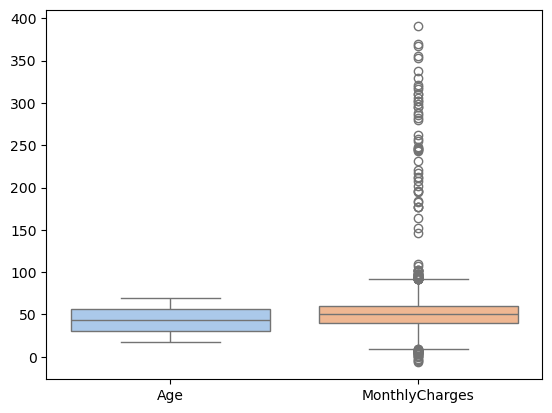

In [52]:
sns.boxplot(data=customer[["Age" , "MonthlyCharges" ]] , palette="pastel")
plt.show()

##### There are possible outliers in Monthlycharges

In [9]:
(customer['MonthlyCharges'] <0).sum()

np.int64(5)

In [10]:
customer[customer['MonthlyCharges']<0]

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
4671,CUST_4671,56.0,Male,Rural,Prepaid,-3.89,2020-11-12
5575,CUST_5575,39.0,Female,Suburban,Monthly,-0.46,2023-02-01
6820,CUST_6820,60.0,Male,Urban,Yearly,-3.15,2018-02-09
8567,CUST_8567,36.0,Male,Rural,Prepaid,-6.72,2018-04-17
9403,CUST_9403,19.0,Male,Rural,Monthly,-4.55,2023-05-18


##### Monthly charge contains 5 negative outliers. Their validity is uncertain, so they will not be removed without further evidence.

### Usage customer : 

#### First 10 lines : 

In [14]:
usage.head(10)

,CustomerID,Month,CallMinutes,DataUsageGB,SMSCount,Complaints
0,CUST_0,2023-01-31,518.12,7.21,9,1
1,CUST_0,2023-02-28,439.79,5.99,35,1
2,CUST_0,2023-03-31,545.06,14.16,14,1
3,CUST_0,2023-04-30,461.78,6.66,40,0
4,CUST_0,2023-05-31,434.82,12.75,26,2
5,CUST_0,2023-06-30,442.07,9.91,24,1
6,CUST_0,2023-07-31,590.26,10.75,13,0
7,CUST_0,2023-08-31,515.54,8.02,32,0
8,CUST_0,2023-09-30,493.27,8.12,41,0
9,CUST_0,2023-10-31,558.78,13.57,39,1


#### The shape of the dataset :

In [15]:
usage.shape

(120000, 6)

#### Name of columns :

In [17]:
usage.columns

Index(['CustomerID', 'Month', 'CallMinutes', 'DataUsageGB', 'SMSCount',
       'Complaints'],
      dtype='object')

#### Data info : 

In [20]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   120000 non-null  object 
 1   Month        120000 non-null  object 
 2   CallMinutes  120000 non-null  float64
 3   DataUsageGB  120000 non-null  float64
 4   SMSCount     120000 non-null  int64  
 5   Complaints   120000 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 5.5+ MB


##### There are no missing values

#### type of variables : 

In [21]:
usage.dtypes

CustomerID      object
Month           object
CallMinutes    float64
DataUsageGB    float64
SMSCount         int64
Complaints       int64
dtype: object

#### Genral statical info : 

In [22]:
usage.describe()

,CallMinutes,DataUsageGB,SMSCount,Complaints
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,492.401958,9.898117,24.525392,0.503000
std,117.443986,3.067815,14.423944,0.708763
min,34.140000,0.000000,0.000000,0.000000
25%,418.450000,7.810000,12.000000,0.000000
50%,494.960000,9.920000,25.000000,0.000000
75%,571.080000,11.980000,37.000000,1.000000
max,914.160000,22.730000,49.000000,6.000000


#### duplicated values :

In [23]:
print(" total dublicate :" , usage.duplicated().sum())

 total dublicate : 0


#### inconsistencies :

In [27]:
for i in [ "Month"] :
    print(i)
    print(usage[i].unique())

Month
['2023-01-31' '2023-02-28' '2023-03-31' '2023-04-30' '2023-05-31'
 '2023-06-30' '2023-07-31' '2023-08-31' '2023-09-30' '2023-10-31'
 '2023-11-30' '2023-12-31']


#### Outliers : 

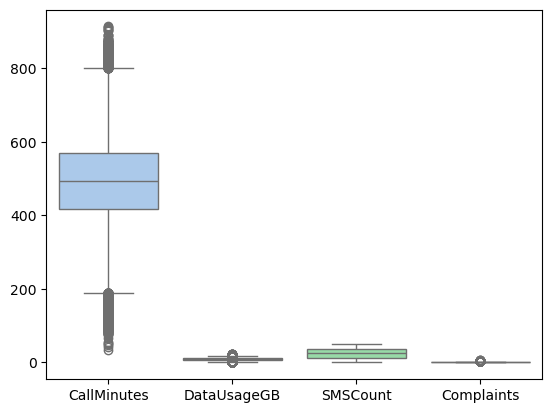

In [51]:
sns.boxplot(data=usage[["CallMinutes" , "DataUsageGB" , "SMSCount" , "Complaints" ]], palette="pastel")
plt.show()

##### There are possible outliers in CallMinutes, SmSCount and Complaints

#### churn labels :

#### First 10 lines : 

In [29]:
churn.head(10)

,CustomerID,Churn
0,CUST_0,0
1,CUST_1,0
2,CUST_2,0
3,CUST_3,0
4,CUST_4,0
5,CUST_5,0
6,CUST_6,0
7,CUST_7,0
8,CUST_8,0
9,CUST_9,0


#### the shape of the dataest : 

In [30]:
churn.shape

(10000, 2)

#### Name of the columns :

In [31]:
churn.columns

Index(['CustomerID', 'Churn'], dtype='object')

#### Data info : 

In [32]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  10000 non-null  object
 1   Churn       10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


#### types of variables : 

In [34]:
churn.dtypes

CustomerID    object
Churn          int64
dtype: object

#### Genral statical info : 

In [35]:
churn.describe()

,Churn
count,10000.000000
mean,0.078600
std,0.269127
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


#### duplicated values : 

In [36]:
print(" total dublicate :" , churn.duplicated().sum())

 total dublicate : 0


#### inconsistencies :

In [39]:
for i in [ "Churn"] :
    print(i)
    print(churn[i].unique())

Churn
[0 1]


#### Outliers :

##### Churn is a binary variable; we don't need to check them

### Cleaning Data : 

In [29]:
customer[customer.duplicated(keep=False)].sort_values('CustomerID')

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate


##### we confirmed that they are true duplicated, now we drop them

In [27]:
customer = customer.drop_duplicates()

In [28]:
customer.duplicated().sum()

np.int64(0)

##### we can't drop customer id because its important in churn dataset and we will merge it
##### MonthlyCharge values, we need to understand their meaning in Eda firstly and then decied

### Merging : 

In [30]:
tel = customer.merge(usage, on="CustomerID" , how="inner")

In [31]:
tel.head(3)

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate,Month,CallMinutes,DataUsageGB,SMSCount,Complaints
0,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-01-31,518.12,7.21,9,1
1,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-02-28,439.79,5.99,35,1
2,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-03-31,545.06,14.16,14,1


In [32]:
telf= tel.merge(churn, on="CustomerID" , how="inner")

In [33]:
telf.head()

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate,Month,CallMinutes,DataUsageGB,SMSCount,Complaints,Churn
0,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-01-31,518.12,7.21,9,1,0
1,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-02-28,439.79,5.99,35,1,0
2,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-03-31,545.06,14.16,14,1,0
3,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-04-30,461.78,6.66,40,0,0
4,CUST_0,NaN,Male,Urban,Yearly,48.18,2021-03-20,2023-05-31,434.82,12.75,26,2,0


In [11]:
telf.shape

(122400, 13)

In [14]:
telf.columns

Index(['CustomerID', 'Age', 'Gender', 'Region', 'ContractType',
       'MonthlyCharges', 'SignupDate', 'Month', 'CallMinutes', 'DataUsageGB',
       'SMSCount', 'Complaints', 'Churn'],
      dtype='object')

In [34]:
print(" total dublicate :" , telf.duplicated().sum())

 total dublicate : 0


### EDA :

In [36]:
telf["Churn"].value_counts()

Churn
0    110616
1      9444
Name: count, dtype: int64

In [37]:
telf["Churn"].value_counts(normalize=True)*100

Churn
0    92.133933
1     7.866067
Name: proportion, dtype: float64

##### 92.14% of customers are not churning and only 7.86% churning

#### the realation between age and churn

In [38]:
telf.groupby("Churn")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,71952.0,43.378085,14.981969,18.0,30.0,43.0,56.0,69.0
1,6084.0,43.812623,14.791612,18.0,32.0,45.0,56.0,69.0


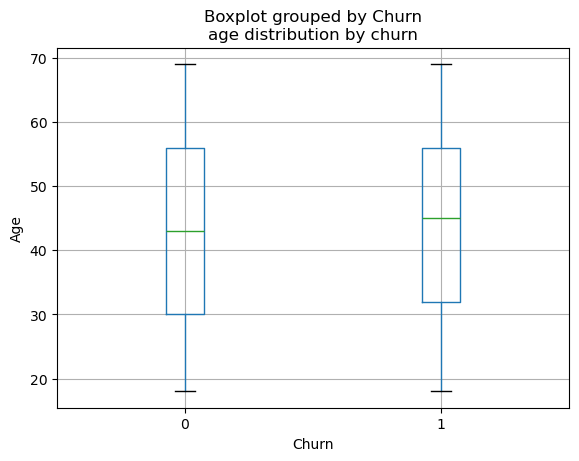

In [39]:
telf.boxplot(column="Age" , by="Churn")
plt.title("age distribution by churn")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

#####  Age distributions are very similar between churned and non-churned customers.
##### Churned customers have a slightly higher median age 45 and 43
##### No significant outliers are observed in either group.

#### Contarct Type 

In [40]:
telf.groupby("Churn")["ContractType"].describe()

,count,unique,top,freq
Churn,,,,
0,110616,3,Prepaid,44784
1,9444,3,Prepaid,3720


In [41]:
telf.groupby('ContractType')['Churn'].mean() * 100

ContractType
Monthly    7.583418
Prepaid    7.669471
Yearly     8.819133
Name: Churn, dtype: float64

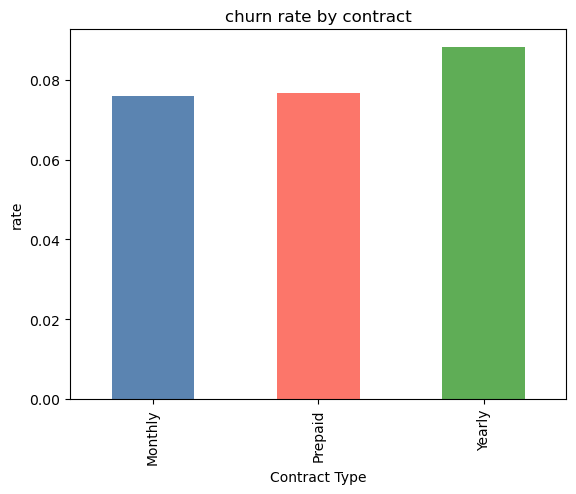

In [42]:
telf.groupby("ContractType")["Churn"].mean().plot(kind="bar", color=['#5B84B1', '#FC766AFF', '#5FAD56'])
plt.title("churn rate by contract")
plt.xlabel("Contract Type")
plt.ylabel("rate")
plt.show()

##### Yearly contract customers have the highest churn rate 8.82%, while Monthly contract customers have the lowest 7.58%. However, the difference is small

#### Region

In [43]:
telf.groupby('Region')['Churn'].mean() * 100

Region
Rural       7.395110
Suburban    8.054086
Urban       8.145897
Name: Churn, dtype: float64

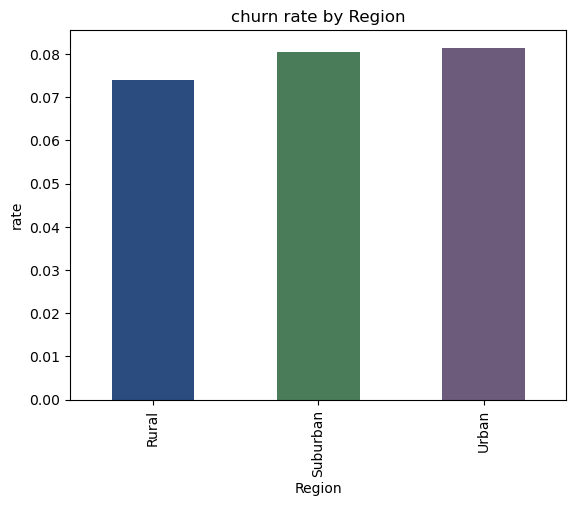

In [68]:
telf.groupby("Region")["Churn"].mean().plot(kind="bar", color=['#2B4C7E', '#4A7C59', '#6C5B7B'])
plt.title("churn rate by Region")
plt.xlabel("Region")
plt.ylabel("rate")
plt.show()

##### Urban customers have the highest churn rate 8.15%, while Rural customers have the lowest 7.39%. However, the differences between regions are small

#### Complaints

In [44]:
telf.groupby('Churn')['Complaints'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,110616.0,0.502061,0.708640,0.0,0.0,0.0,1.0,6.0
1,9444.0,0.514295,0.710958,0.0,0.0,0.0,1.0,5.0


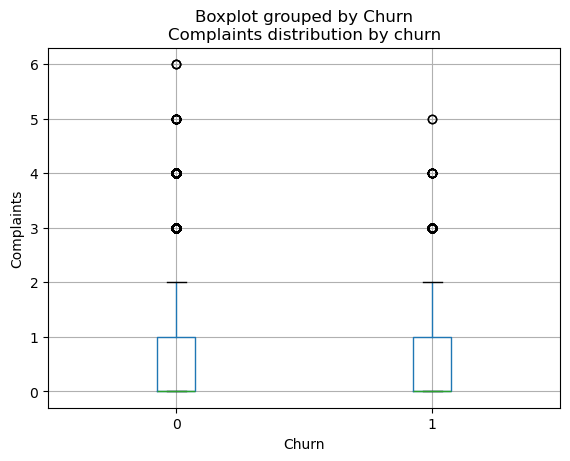

In [45]:
telf.boxplot(column="Complaints" , by="Churn")
plt.title("Complaints distribution by churn")
plt.xlabel("Churn")
plt.ylabel("Complaints")
plt.show()

##### The distribution of complaints is very similar between churned and non churned customers. Most customers have a low number of complaints around 0 to 2, with a few outliers showing higher complaint counts in both groups. This suggests that the number of complaints alone may not be a strong direct indicator of customer churn.

#### Monthly Charge

In [46]:
telf.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,110616.0,51.065332,21.500843,-6.72,39.76,50.09,60.58,390.3
1,9444.0,50.220737,21.962911,2.83,40.26,48.69,59.40,318.5


In [48]:
telf[telf['MonthlyCharges'] < 0][['CustomerID', 'MonthlyCharges', 'Churn']]

,CustomerID,MonthlyCharges,Churn
56052,CUST_4671,-3.89,0
56053,CUST_4671,-3.89,0
56054,CUST_4671,-3.89,0
56055,CUST_4671,-3.89,0
56056,CUST_4671,-3.89,0
56057,CUST_4671,-3.89,0
56058,CUST_4671,-3.89,0
56059,CUST_4671,-3.89,0
56060,CUST_4671,-3.89,0
56061,CUST_4671,-3.89,0


In [52]:
telf[telf['CustomerID'] == 'CUST_4671'][['CustomerID', 'MonthlyCharges', 'Churn']]

,CustomerID,MonthlyCharges,Churn
56052,CUST_4671,-3.89,0
56053,CUST_4671,-3.89,0
56054,CUST_4671,-3.89,0
56055,CUST_4671,-3.89,0
56056,CUST_4671,-3.89,0
56057,CUST_4671,-3.89,0
56058,CUST_4671,-3.89,0
56059,CUST_4671,-3.89,0
56060,CUST_4671,-3.89,0
56061,CUST_4671,-3.89,0


In [55]:
telf.groupby('CustomerID')['Churn'].nunique().value_counts()

Churn
1    10000
Name: count, dtype: int64

In [58]:
telf[telf['MonthlyCharges'] < 0][
    ['CustomerID', 'MonthlyCharges', 'Churn']].drop_duplicates()


,CustomerID,MonthlyCharges,Churn
56052,CUST_4671,-3.89,0
66900,CUST_5575,-0.46,0
81840,CUST_6820,-3.15,0
102804,CUST_8567,-6.72,0
112836,CUST_9403,-4.55,0


##### Five customers have negative MonthlyCharges values. These values remain consistent across all 12 monthly records and all five customers belong to the non churn group. Since their business meaning is unclear, the values were retained rather than removed.

In [71]:
customercharges = telf.groupby('CustomerID').agg(AvgMonthlyCharges=('MonthlyCharges', 'mean'), Churn=('Churn', 'first'))
customercharges.groupby('Churn')['AvgMonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,9214.0,51.066188,21.504876,-6.72,39.7625,50.09,60.5800,390.3
1,786.0,50.227150,21.988970,2.83,40.3100,48.70,59.3975,318.5


##### Average monthly charges are very similar between churned and non churned customers, with mean values of 50.23 and 51.07 respectively. This suggests that monthly charges alone do not show a clear difference between the two groups.

#### Call minutes 

In [76]:
customercalls = telf.groupby('CustomerID').agg( AvgCallMinutes=('CallMinutes', 'mean'))
customercalls['Churn'] = telf.groupby('CustomerID')['Churn'].first()

In [79]:
customercalls.groupby('Churn')['AvgCallMinutes'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,9214.0,492.195052,100.515281,112.025000,422.848333,491.409167,561.700208,833.326667
1,786.0,494.827451,100.068712,226.405833,427.322708,495.536667,555.638750,792.557500


##### Average call minutes is very similar between churned and nonchurned customers, with mean values of 494.83 and 492.20 minutes respectively. This suggests that call usage alone does not show a clear difference between the two groups

In [83]:
customerdata = telf.groupby('CustomerID').agg(AvgDataUsage=('DataUsageGB', 'mean'))
customerdata['Churn'] = telf.groupby('CustomerID')['Churn'].first()

In [85]:
customerdata.groupby('Churn')['AvgDataUsage'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,9214.0,9.900067,0.922950,6.609167,9.290208,9.91750,10.527292,12.720000
1,786.0,9.875262,0.908425,6.780833,9.271875,9.91625,10.480833,13.723333


##### Average data usage is very similar between churned and non churned customers, with mean values of 9.88 and 9.90 respectively. This suggests that data usage alone does not show a clear difference between the two groups

#### SMS Count 

In [87]:
customersms = telf.groupby('CustomerID').agg(AvgSMSCount=('SMSCount', 'mean'))
customersms['Churn'] = telf.groupby('CustomerID')['Churn'].first()

In [89]:
customersms.groupby('Churn')['AvgSMSCount'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,9214.0,24.498182,4.163255,8.583333,21.666667,24.458333,27.333333,39.333333
1,786.0,24.844360,4.164031,12.250000,21.958333,24.791667,27.333333,37.916667


##### Average SMS usage is very similar between churned and non churned customers, with mean values of 24.84 and 24.50 respectively. This suggests that SMS usage alone does not show a clear difference between the two groups

#### Correlation